In [5]:
pip install -qU langchain-graph-retriever langchain-experimental

ERROR: Could not find a version that satisfies the requirement langchain-graph-retriever (from versions: none)
ERROR: No matching distribution found for langchain-graph-retriever
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install langchain_experimental

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 209 kB 2.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [12]:
import os
import networkx as nx
import matplotlib.pyplot as plt
from langchain_openai import ChatOpenAI
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_core.documents import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.prompts import PromptTemplate


Extracting graph from text using Groq API...

Nodes: ['Albert Einstein', 'Germany', 'Ulm', 'United States', 'Princeton University', 'Nobel Prize in Physics', 'theory of relativity', 'physics']

Edges:
  Albert Einstein --[born in]--> Ulm
  Albert Einstein --[from]--> Germany
  Albert Einstein --[won]--> Nobel Prize in Physics
  Albert Einstein --[won]--> Nobel Prize in Physics
  Albert Einstein --[moved to]--> United States
  Albert Einstein --[worked at]--> Princeton University
  Albert Einstein --[developed]--> theory of relativity
  theory of relativity --[revolutionized]--> physics

Graph created: 8 nodes, 7 edges


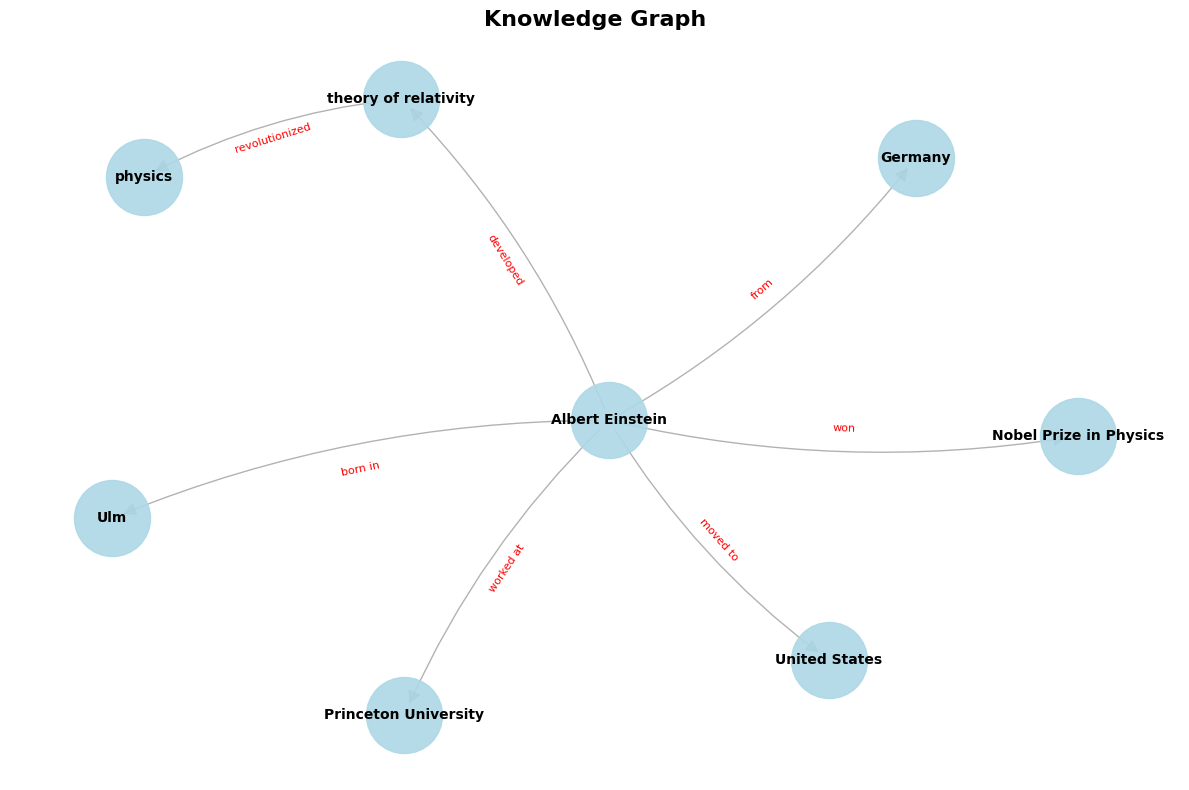


Graph saved to knowledge_graph.png


In [ ]:
import os
from groq import Groq
import networkx as nx
import matplotlib.pyplot as plt
import json
import re
from api import api_key
# Initialize Groq client
client = Groq(api_key=api_key)


def extract_graph_from_text(text):
    """Extract nodes and edges from text using Groq API."""
    
    prompt = f"""Extract entities (nodes) and relationships (edges) from the following text.
Return the result in this exact JSON format:
{{
  "nodes": ["entity1", "entity2", "entity3"],
  "edges": [
    {{"source": "entity1", "relation": "relationship_type", "target": "entity2"}},
    {{"source": "entity2", "relation": "relationship_type", "target": "entity3"}}
  ]
}}

Text: {text}

JSON:"""
    
    # Call Groq API
    response = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": "You are a knowledge graph extraction assistant. Always return valid JSON."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        model="llama-3.1-8b-instant",  # Fast and free model
        temperature=0.1,
        max_tokens=1024
    )
    
    # Extract response
    result = response.choices[0].message.content
    
    # Parse JSON (handle potential markdown code blocks)
    result = result.strip()
    # if result.startswith("```)
    #     result = re.sub(r"```json\n?|\n?```
    
    graph_data = json.loads(result)
    return graph_data


def create_graph(graph_data):
    """Create NetworkX graph from extracted data."""
    G = nx.DiGraph()
    
    # Add nodes
    for node in graph_data["nodes"]:
        G.add_node(node)
    
    # Add edges
    for edge in graph_data["edges"]:
        G.add_edge(edge["source"], edge["target"], relation=edge["relation"])
    
    return G


def plot_graph(graph):
    """Visualize the knowledge graph."""
    if len(graph.nodes()) == 0:
        print("Graph is empty!")
        return
    
    plt.figure(figsize=(12, 8))
    
    # Layout
    pos = nx.spring_layout(graph, k=1, iterations=50)
    
    # Draw nodes
    nx.draw_networkx_nodes(
        graph, pos,
        node_color='lightblue',
        node_size=3000,
        alpha=0.9
    )
    
    # Draw edges
    nx.draw_networkx_edges(
        graph, pos,
        edge_color='gray',
        arrows=True,
        arrowsize=20,
        alpha=0.6,
        connectionstyle="arc3,rad=0.1"
    )
    
    # Draw labels
    nx.draw_networkx_labels(
        graph, pos,
        font_size=10,
        font_weight='bold'
    )
    
    # Draw edge labels (relations)
    edge_labels = nx.get_edge_attributes(graph, 'relation')
    nx.draw_networkx_edge_labels(
        graph, pos,
        edge_labels=edge_labels,
        font_size=8,
        font_color='red'
    )
    
    plt.title("Knowledge Graph", fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("knowledge_graph.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("\nGraph saved to knowledge_graph.png")


# Example usage
if __name__ == "__main__":
    # Input text
    text = """
    Albert Einstein was a German physicist who developed the theory of relativity.
    He was born in Ulm, Germany in 1879. Einstein won the Nobel Prize in Physics 
    in 1921. He moved to the United States in 1933 and worked at Princeton University.
    The theory of relativity revolutionized modern physics.
    """
    
    print("Extracting graph from text using Groq API...")
    
    # Extract graph data
    graph_data = extract_graph_from_text(text)
    
    # Print extracted data
    print(f"\nNodes: {graph_data['nodes']}")
    print(f"\nEdges:")
    for edge in graph_data['edges']:
        print(f"  {edge['source']} --[{edge['relation']}]--> {edge['target']}")
    
    # Create graph
    graph = create_graph(graph_data)
    print(f"\nGraph created: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Visualize
    plot_graph(graph)


Extracting graph from text using Groq API...

Nodes: ['PP-0073', 'TOE', 'HAN', 'LMN', 'ST author', 'Federal Office for Information Security', 'Functional package: Multiple grid connection points', 'GWA', 'Consumer', 'Grid connection points', 'Grid node', 'Voltage level', 'Meter', 'SMGW', 'IT equipment', 'Properties', 'Assets', 'Assumptions', 'PhysicalProtection', 'ExtensionLocalNetwork', 'Attackers', 'Local attacker', 'Threats', 'T.DataModificationLocal', 'T.TimeModification', 'T.DisclosureLocal', 'T.ResidualData']

Edges:
  PP-0073 --[depends_on]--> TOE
  TOE --[installed_in]--> Environment
  Environment --[covers]--> PhysicalProtection
  PhysicalProtection --[covers]--> TOE
  PhysicalProtection --[covers]--> Communication channel
  TOE --[communicates_with]--> Security module
  Security module --[communicates_with]--> TOE
  TOE --[located_in]--> HAN
  TOE --[located_in]--> LMN
  HAN --[interconnects]--> IT equipment
  HAN --[interconnects]--> SMGW
  LMN --[connects]--> Meter
  LMN --

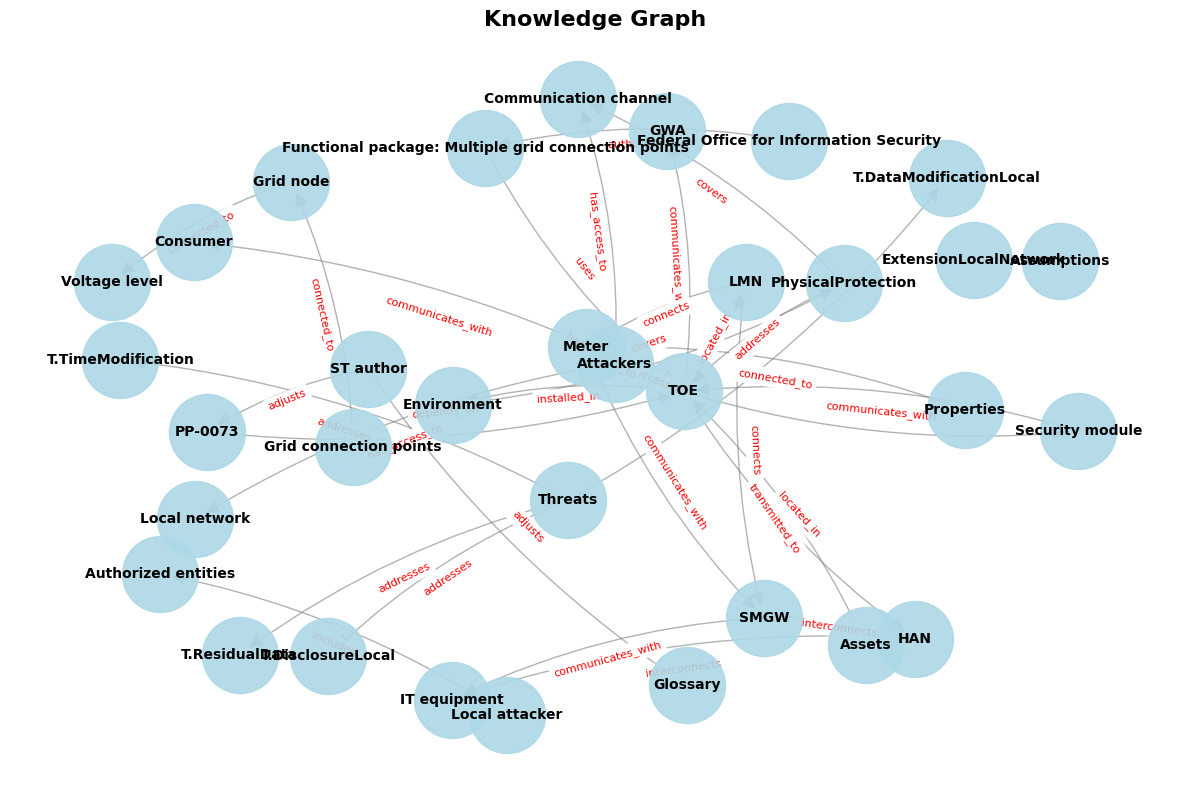


Graph saved to knowledge_graph.png


In [25]:
# Example usage
if __name__ == "__main__":
    # Input text
    text = """
1.2 Package overview
This functional package depends on the base PP [PP-0073].
This functional package shall be used if the TOE is intended to be installed in an environment, where it cannot
be assumed that all connected meters are covered by the same physical protection as the TOE. In particular, the
bundling of devices of grid connection points with one TOE is permitted for grid connection points connected
to one grid node of the same voltage level.
The threat model in [PP-0073] Chapter 3 does not cover this scenario; in particular, not all attack vectors of
this scenario are addressed in the threat model of the base PP. Therefore, the following section describes a
security problem definition for this use case of the TOE. Note that this security problem definition adds to the
security problem definition of the base PP, and that this functional package shall only be used in combination
with the base PP.
The ST author shall further adjust [PP-0073] Chapter 1 to address this use case.
1.3 Definition of terms
In the base PP, the networks HAN and LMN are considered to be in-house networks, see [PP-0073], Glossary.
For the use case of this functional package, however, this consideration does not hold any more. The ST author
shall therefore adjust the definition of these networks as follows.
Term Description
HAN Local data communication network which interconnects IT equipment with the SMGW and can e.g. be
used for energy management purposes. The expansion of the network is restricted to the distance bet-
ween SMGW and the properties with connected meters.
LMN Local data communication network which connects meters with the SMGW. The expansion of the net-
work is restricted to the distance between SMGW and the properties with connected meters.
Table 1.2 Adjustments to the glossary from the base PP for the functional package multiple grid connection points
1.4 Security problem definition
1.4.1 Assets
This package does not contain any additional assets.
Federal Office for Information Security 1
1 Functional package: Multiple grid connection points
1.4.2 Assumptions
The following assumptions shall be adjusted from the base PP if this functional package is chosen.
A.PhysicalProtection It is assumed that the TOE is installed
• either in a non-public environment within a closed facility with restricted access1,
which provides an enhanced-basic level of physical protection. This protection
covers the TOE as well as the communication channel between the TOE and its
security module,
• or in a public environment within a casing which provides an enhanced-basic le-
vel of physical protection for the TOE and which restricts direct access to the TOE.
This protection covers the TOE as well as the communication channel between
the TOE and its security module.
In both cases, it is assumed that the operational environment ensures that physical
tampering of the TOE is detectable and that the GWA and the consumer are notified
without undue delay in case physical tampering has occurred.
A.ExtensionLocalNet-
work
It is assumed that the spatial expansion of the networks HAN and LMN is restricted
to the distance of the TOE to connected devices of bundled grid connection points.
A bundling of grid connection points with one TOE is permitted provided that the
grid connection points are connected to one grid node of the same voltage level.
1.4.3 Attackers
The definition of the local attacker in [PP-0073], Section 3.4 in the base PP shall be replaced by the following
definition.
Local attacker: An attacker that
• either has physical access to meter, TOE, a connection between these components, or local logical access
to any of the interfaces, who tries to disclose or alter assets while stored in the TOE or while transmitted
between external entities and the TOE;
• or is located in the HAN or LMN and tries to disclose or alter assets transmitted via these networks.
Considering the limited value of information processed by a single TOE (resulting in a lower attack motivati-
on in comparison to remote attacks on a large number of TOEs), the following threat model assumes for the
vulnerability assessment, that local attackers have at most proficient expertise and use at most specialized
equipment. However, the preparation of local attacks in terms of developing the attack path including tools
can be performed by attackers with full AVA_VAN.5 attack potential (i.e., multiple expert expertise and mul-
tiple bespoke equipment), as long as their execution is possible with the restrictions for local attackers men-
tioned above (also for all remote attacks (cf. following bullet point) the full AVA_VAN.5 attack potential has
to be assumed during the vulnerability assessment).
Please note that the local attacker includes authorized entities like consumers or other entities having access
to the environment where the TOE is located.
1.4.4 Threats
This package does not contain any additional threats. Note, however, that by adjusting the definition of the
local attacker, all threats with the threat agent being a local attacker address a wider range of attack vectors.
This concerns the following threats:
• T.DataModificationLocal
• T.TimeModification
• T.DisclosureLocal
• T.ResidualData
1    """
    
    print("Extracting graph from text using Groq API...")
    
    # Extract graph data
    graph_data = extract_graph_from_text(text)
    
    # Print extracted data
    print(f"\nNodes: {graph_data['nodes']}")
    print(f"\nEdges:")
    for edge in graph_data['edges']:
        print(f"  {edge['source']} --[{edge['relation']}]--> {edge['target']}")
    
    # Create graph
    graph = create_graph(graph_data)
    print(f"\nGraph created: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Visualize
    plot_graph(graph)


In [ ]:
"""
Hierarchical Document Knowledge Graph (DKG) Builder
====================================================
Architecture: Document → Section/Heading → Paragraph → Entity

Instead of extracting every entity from the entire text in one flat call,
this builds a structured graph that mirrors document hierarchy. The LLM
is only called at the paragraph level for entity extraction, making it
far more efficient and the graph far more navigable for retrieval.

Inspired by:
- Document GraphRAG (2025) — dual DKG/IKG architecture
- LightRAG (2024) — incremental, dual-level retrieval
- PathRAG (2025) — path-based pruning for precision
"""

import os
import re
import json
import hashlib
from dataclasses import dataclass, field
from typing import Optional
from groq import Groq
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# 1. DATA STRUCTURES
# ─────────────────────────────────────────────

@dataclass
class Paragraph:
    """A single paragraph within a section."""
    id: str
    text: str
    section_id: str
    order: int  # position within section

@dataclass
class Section:
    """A heading/section within a document."""
    id: str
    title: str
    level: int  # heading depth (1 = H1, 2 = H2, etc.)
    doc_id: str
    parent_section_id: Optional[str] = None
    paragraphs: list = field(default_factory=list)

@dataclass
class Document:
    """Top-level document node."""
    id: str
    name: str
    source_path: str
    sections: list = field(default_factory=list)


# ─────────────────────────────────────────────
# 2. DOCUMENT PARSER — Structure Extraction
# ─────────────────────────────────────────────

class DocumentParser:
    """
    Parses raw text into a Document → Section → Paragraph hierarchy.
    
    Supports:
      - Markdown headings (# / ## / ###)
      - Numbered headings (1. / 1.1 / 1.1.1)
      - ALL-CAPS headings (common in German technical docs)
      - Fallback: treats entire text as one section
    """

    # Patterns for heading detection
    MARKDOWN_HEADING = re.compile(r'^(#{1,4})\s+(.+)$', re.MULTILINE)
    NUMBERED_HEADING = re.compile(r'^(\d+(?:\.\d+)*)\s+([A-ZÜÖÄ].{2,80})$', re.MULTILINE)
    ALLCAPS_HEADING  = re.compile(r'^([A-ZÜÖÄ][A-ZÜÖÄ\s\-]{4,80})$', re.MULTILINE)

    @staticmethod
    def _make_id(*parts):
        """Create a deterministic short ID from parts."""
        raw = "|".join(str(p) for p in parts)
        return hashlib.md5(raw.encode()).hexdigest()[:10]

    def parse(self, text: str, doc_name: str = "document", source_path: str = "") -> Document:
        """Parse text into structured Document object."""
        doc_id = self._make_id(doc_name, source_path)
        doc = Document(id=doc_id, name=doc_name, source_path=source_path)

        # Try to detect heading style
        sections = self._split_by_headings(text, doc_id)

        if not sections:
            # Fallback: no headings found — treat as single section
            sec_id = self._make_id(doc_id, "root")
            section = Section(id=sec_id, title=doc_name, level=1, doc_id=doc_id)
            section.paragraphs = self._split_paragraphs(text, sec_id)
            sections = [section]

        doc.sections = sections
        return doc

    def _split_by_headings(self, text: str, doc_id: str) -> list:
        """Detect and split text by headings into Section objects."""
        # Try markdown first
        markers = [(m.start(), len(m.group(1)), m.group(2).strip())
                    for m in self.MARKDOWN_HEADING.finditer(text)]

        # Try numbered headings if no markdown found
        if not markers:
            markers = [(m.start(), m.group(1).count('.') + 1, m.group(2).strip())
                        for m in self.NUMBERED_HEADING.finditer(text)]

        # Try ALL-CAPS headings
        if not markers:
            markers = [(m.start(), 1, m.group(1).strip())
                        for m in self.ALLCAPS_HEADING.finditer(text)
                        if len(m.group(1).strip().split()) <= 8]  # max 8 words

        if not markers:
            return []

        sections = []
        section_stack = {}  # level -> section_id for parent tracking

        for i, (pos, level, title) in enumerate(markers):
            # Extract text between this heading and the next
            start = pos + len(title) + level + 1  # skip heading line
            end = markers[i + 1][0] if i + 1 < len(markers) else len(text)
            body = text[start:end].strip()

            sec_id = self._make_id(doc_id, title, i)
            parent_id = section_stack.get(level - 1)

            section = Section(
                id=sec_id,
                title=title,
                level=level,
                doc_id=doc_id,
                parent_section_id=parent_id
            )
            section.paragraphs = self._split_paragraphs(body, sec_id)

            section_stack[level] = sec_id
            sections.append(section)

        return sections

    def _split_paragraphs(self, text: str, section_id: str) -> list:
        """Split section body into paragraph objects."""
        # Split on double newlines or single newlines with blank lines
        raw_paras = re.split(r'\n\s*\n', text.strip())
        paragraphs = []

        for i, para_text in enumerate(raw_paras):
            cleaned = para_text.strip()
            if len(cleaned) < 10:  # skip trivially short fragments
                continue
            para_id = self._make_id(section_id, i)
            paragraphs.append(Paragraph(
                id=para_id,
                text=cleaned,
                section_id=section_id,
                order=i
            ))

        return paragraphs


# ─────────────────────────────────────────────
# 3. ENTITY EXTRACTOR — LLM calls at paragraph level only
# ─────────────────────────────────────────────

class EntityExtractor:
    """
    Extracts entities and relations using an LLM — but ONLY at the
    paragraph level. This is the key efficiency gain: instead of one
    massive extraction over the whole document, we make small, focused
    calls per paragraph and merge results via the graph structure.
    
    Paragraphs below a token threshold are skipped (no useful entities
    in a 2-word paragraph).
    """

    PROMPT_TEMPLATE = """Extract the key technical entities and their relationships from this paragraph.
Focus on: components, specifications, procedures, standards, materials, measurements, and their connections.

Return ONLY valid JSON in this exact format:
{{
  "entities": ["entity1", "entity2"],
  "relations": [
    {{"source": "entity1", "relation": "relationship", "target": "entity2"}}
  ]
}}

Rules:
- Normalize entity names (e.g., "the motor" → "Motor", "100 Nm torque" → "100 Nm")
- Keep entities concise (2-5 words max)
- Only extract meaningful domain entities, skip pronouns and generic words
- If no entities found, return {{"entities": [], "relations": []}}

Paragraph:
{text}

JSON:"""

    def __init__(self, api_key: str, model: str = "llama-3.1-8b-instant",
                 min_paragraph_length: int = 30):
        self.client = Groq(api_key=api_key)
        self.model = model
        self.min_length = min_paragraph_length
        self._cache = {}  # paragraph text hash → extracted data

    def extract(self, paragraph: Paragraph) -> dict:
        """Extract entities and relations from a single paragraph."""
        # Skip short paragraphs — no useful entities
        if len(paragraph.text) < self.min_length:
            return {"entities": [], "relations": []}

        # Cache check — avoid re-extracting identical paragraphs
        text_hash = hashlib.md5(paragraph.text.encode()).hexdigest()
        if text_hash in self._cache:
            return self._cache[text_hash]

        prompt = self.PROMPT_TEMPLATE.format(text=paragraph.text)

        try:
            response = self.client.chat.completions.create(
                messages=[
                    {"role": "system", "content": "You are a technical entity extraction assistant. Return only valid JSON, no markdown."},
                    {"role": "user", "content": prompt}
                ],
                model=self.model,
                temperature=0.0,
                max_tokens=512
            )

            result = response.choices[0].message.content.strip()

            # Clean markdown fences if present
            result = re.sub(r'^```(?:json)?\s*', '', result)
            result = re.sub(r'\s*```$', '', result)

            data = json.loads(result)

            # Validate structure
            if "entities" not in data:
                data["entities"] = []
            if "relations" not in data:
                data["relations"] = []

        except (json.JSONDecodeError, Exception) as e:
            print(f"  [WARN] Extraction failed for paragraph {paragraph.id}: {e}")
            data = {"entities": [], "relations": []}

        self._cache[text_hash] = data
        return data


# ─────────────────────────────────────────────
# 4. HIERARCHICAL GRAPH BUILDER
# ─────────────────────────────────────────────

class HierarchicalGraphBuilder:
    """
    Builds a NetworkX graph with this structure:
    
        [Document]
            │
            ├── [Section: "1. Introduction"]
            │       ├── [Paragraph 1]
            │       │       ├── (Entity A)
            │       │       └── (Entity B) ──relation──▶ (Entity A)
            │       └── [Paragraph 2]
            │               └── (Entity C)
            │
            └── [Section: "2. Specifications"]
                    └── [Paragraph 3]
                            ├── (Entity D)
                            └── (Entity E)
    
    Node types: "document", "section", "paragraph", "entity"
    Edge types: "has_section", "has_subsection", "has_paragraph",
                "contains_entity", and domain-specific relations
    """

    # Color scheme for visualization
    NODE_COLORS = {
        "document":  "#1a1a2e",   # dark navy
        "section":   "#16213e",   # deep blue
        "paragraph": "#0f3460",   # medium blue
        "entity":    "#e94560",   # coral red
    }

    NODE_SIZES = {
        "document":  4000,
        "section":   2500,
        "paragraph": 1200,
        "entity":    800,
    }

    def __init__(self, extractor: EntityExtractor):
        self.extractor = extractor
        self.graph = nx.DiGraph()
        self._entity_registry = {}  # normalized name → node_id (for dedup)

    def build(self, document: Document) -> nx.DiGraph:
        """Build the full hierarchical graph from a parsed document."""
        print(f"\n{'='*60}")
        print(f"  Building graph for: {document.name}")
        print(f"{'='*60}")

        # 1. Add document node
        self.graph.add_node(document.id,
                           label=document.name,
                           node_type="document",
                           source=document.source_path)
        
        total_entities = 0
        total_relations = 0

        # 2. Add sections
        for section in document.sections:
            self.graph.add_node(section.id,
                               label=section.title,
                               node_type="section",
                               level=section.level)

            # Connect section to parent (document or parent section)
            if section.parent_section_id and section.parent_section_id in self.graph:
                self.graph.add_edge(section.parent_section_id, section.id,
                                   relation="has_subsection")
            else:
                self.graph.add_edge(document.id, section.id,
                                   relation="has_section")

            print(f"\n  Section: '{section.title}' ({len(section.paragraphs)} paragraphs)")

            # 3. Add paragraphs and extract entities
            for para in section.paragraphs:
                self.graph.add_node(para.id,
                                   label=f"¶{para.order + 1}",
                                   node_type="paragraph",
                                   text=para.text[:200])  # store preview
                self.graph.add_edge(section.id, para.id,
                                   relation="has_paragraph")

                # 4. LLM extraction — only at paragraph level
                extracted = self.extractor.extract(para)

                # 5. Add entities (with deduplication)
                for entity_name in extracted["entities"]:
                    entity_id = self._add_entity(entity_name)
                    self.graph.add_edge(para.id, entity_id,
                                       relation="contains_entity")
                    total_entities += 1

                # 6. Add inter-entity relations
                for rel in extracted["relations"]:
                    src_id = self._add_entity(rel["source"])
                    tgt_id = self._add_entity(rel["target"])
                    self.graph.add_edge(src_id, tgt_id,
                                       relation=rel.get("relation", "related_to"))
                    total_relations += 1

                n_ent = len(extracted["entities"])
                n_rel = len(extracted["relations"])
                if n_ent > 0:
                    print(f"    ¶{para.order + 1}: {n_ent} entities, {n_rel} relations")

        # Summary
        n_types = {}
        for _, data in self.graph.nodes(data=True):
            t = data.get("node_type", "unknown")
            n_types[t] = n_types.get(t, 0) + 1

        print(f"\n{'─'*60}")
        print(f"  Graph built successfully!")
        print(f"  Nodes: {self.graph.number_of_nodes()} total")
        for t, c in sorted(n_types.items()):
            print(f"    - {t}: {c}")
        print(f"  Edges: {self.graph.number_of_edges()} total")
        print(f"  Unique entities: {len(self._entity_registry)}")
        print(f"{'─'*60}")

        return self.graph

    def _add_entity(self, name: str) -> str:
        """Add an entity node with name normalization and deduplication."""
        normalized = name.strip().title()

        if normalized in self._entity_registry:
            return self._entity_registry[normalized]

        entity_id = f"ent_{hashlib.md5(normalized.encode()).hexdigest()[:8]}"
        self._entity_registry[normalized] = entity_id
        self.graph.add_node(entity_id,
                           label=normalized,
                           node_type="entity")
        return entity_id


# ─────────────────────────────────────────────
# 5. RETRIEVER — Hierarchical graph traversal
# ─────────────────────────────────────────────

class HierarchicalRetriever:
    """
    Retrieves context by traversing the graph top-down:
    
    1. Find matching entities for the query
    2. Trace upward: entity → paragraph → section → document
    3. Collect sibling paragraphs from the same section for context
    4. Return ranked passages with full provenance
    
    This gives you BOTH the precise answer AND its location in
    the document hierarchy.
    """

    def __init__(self, graph: nx.DiGraph):
        self.graph = graph

    def retrieve(self, query_entities: list, top_k: int = 5) -> list:
        """
        Given a list of query entities (strings), find matching graph
        entities and return their paragraph contexts with provenance.
        """
        results = []

        for query_ent in query_entities:
            normalized = query_ent.strip().title()

            # Find matching entity nodes (exact or substring match)
            for node_id, data in self.graph.nodes(data=True):
                if data.get("node_type") != "entity":
                    continue
                label = data.get("label", "")
                if normalized in label or label in normalized:
                    # Trace upward to get provenance
                    provenance = self._trace_provenance(node_id)
                    if provenance:
                        results.append({
                            "entity": label,
                            "entity_id": node_id,
                            **provenance
                        })

        # Deduplicate by paragraph and sort by relevance (number of matched entities)
        seen = set()
        unique_results = []
        for r in results:
            if r.get("paragraph_id") not in seen:
                seen.add(r.get("paragraph_id"))
                unique_results.append(r)

        return unique_results[:top_k]

    def _trace_provenance(self, entity_id: str) -> dict:
        """Trace from entity up through paragraph → section → document."""
        # Find parent paragraph
        for pred in self.graph.predecessors(entity_id):
            pred_data = self.graph.nodes[pred]
            if pred_data.get("node_type") == "paragraph":
                para_id = pred
                para_text = pred_data.get("text", "")

                # Find parent section
                for sec_pred in self.graph.predecessors(para_id):
                    sec_data = self.graph.nodes[sec_pred]
                    if sec_data.get("node_type") == "section":
                        section_title = sec_data.get("label", "")

                        # Find parent document
                        for doc_pred in self.graph.predecessors(sec_pred):
                            doc_data = self.graph.nodes[doc_pred]
                            if doc_data.get("node_type") in ("document", "section"):
                                return {
                                    "paragraph_id": para_id,
                                    "paragraph_text": para_text,
                                    "section": section_title,
                                    "document": doc_data.get("label", "")
                                }
        return None


# ─────────────────────────────────────────────
# 6. VISUALIZATION
# ─────────────────────────────────────────────

def plot_hierarchical_graph(graph: nx.DiGraph, output_path: str = "knowledge_graph.png"):
    """
    Visualize the hierarchical knowledge graph with color-coded node types.
    Uses a hierarchical layout that reflects the document structure.
    """
    if graph.number_of_nodes() == 0:
        print("Graph is empty!")
        return

    fig, ax = plt.subplots(1, 1, figsize=(18, 12))
    fig.patch.set_facecolor('#0a0a1a')
    ax.set_facecolor('#0a0a1a')

    # Assign colors and sizes based on node type
    colors = []
    sizes = []
    labels = {}
    for node, data in graph.nodes(data=True):
        node_type = data.get("node_type", "entity")
        colors.append(HierarchicalGraphBuilder.NODE_COLORS.get(node_type, "#e94560"))
        sizes.append(HierarchicalGraphBuilder.NODE_SIZES.get(node_type, 800))
        label = data.get("label", node)
        # Truncate long labels
        labels[node] = label[:25] + "…" if len(label) > 25 else label

    # Hierarchical layout using Kamada-Kawai (works well for trees)
    try:
        pos = nx.kamada_kawai_layout(graph)
    except Exception:
        pos = nx.spring_layout(graph, k=2, iterations=100, seed=42)

    # Draw edges with different styles for structural vs semantic edges
    structural_edges = []
    semantic_edges = []
    for u, v, data in graph.edges(data=True):
        rel = data.get("relation", "")
        if rel in ("has_section", "has_subsection", "has_paragraph", "contains_entity"):
            structural_edges.append((u, v))
        else:
            semantic_edges.append((u, v))

    # Draw structural edges (thin, faded)
    nx.draw_networkx_edges(graph, pos, edgelist=structural_edges,
                           edge_color='#334466', arrows=True, arrowsize=12,
                           alpha=0.4, width=1.0, style='solid',
                           connectionstyle="arc3,rad=0.05", ax=ax)

    # Draw semantic edges (bright, prominent)
    nx.draw_networkx_edges(graph, pos, edgelist=semantic_edges,
                           edge_color='#ff6b6b', arrows=True, arrowsize=15,
                           alpha=0.7, width=1.5, style='solid',
                           connectionstyle="arc3,rad=0.15", ax=ax)

    # Draw nodes
    nx.draw_networkx_nodes(graph, pos, node_color=colors, node_size=sizes,
                           alpha=0.9, edgecolors='#ffffff', linewidths=0.5, ax=ax)

    # Draw labels
    nx.draw_networkx_labels(graph, pos, labels=labels,
                            font_size=7, font_color='white',
                            font_weight='bold', ax=ax)

    # Draw edge labels for semantic relations only
    semantic_edge_labels = {}
    for u, v, data in graph.edges(data=True):
        rel = data.get("relation", "")
        if rel not in ("has_section", "has_subsection", "has_paragraph", "contains_entity"):
            semantic_edge_labels[(u, v)] = rel
    if semantic_edge_labels:
        nx.draw_networkx_edge_labels(graph, pos, edge_labels=semantic_edge_labels,
                                     font_size=6, font_color='#ffaa00', ax=ax)

    # Legend
    legend_items = [
        mpatches.Patch(color='#1a1a2e', label='Document'),
        mpatches.Patch(color='#16213e', label='Section'),
        mpatches.Patch(color='#0f3460', label='Paragraph'),
        mpatches.Patch(color='#e94560', label='Entity'),
        mpatches.Patch(color='#ff6b6b', label='─ Semantic Relation'),
        mpatches.Patch(color='#334466', label='─ Structural Link'),
    ]
    ax.legend(handles=legend_items, loc='upper left', fontsize=9,
              facecolor='#0a0a1a', edgecolor='#334466', labelcolor='white')

    ax.set_title("Hierarchical Document Knowledge Graph",
                 fontsize=16, fontweight='bold', color='white', pad=20)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"\nGraph saved to {output_path}")


# ─────────────────────────────────────────────
# 7. MAIN — Full Pipeline
# ─────────────────────────────────────────────

if __name__ == "__main__":

    # ── Example: German-style technical document ──
    sample_text = """
1.2 Package overview
This functional package depends on the base PP [PP-0073].
This functional package shall be used if the TOE is intended to be installed in an environment, where it cannot
be assumed that all connected meters are covered by the same physical protection as the TOE. In particular, the
bundling of devices of grid connection points with one TOE is permitted for grid connection points connected
to one grid node of the same voltage level.
The threat model in [PP-0073] Chapter 3 does not cover this scenario; in particular, not all attack vectors of
this scenario are addressed in the threat model of the base PP. Therefore, the following section describes a
security problem definition for this use case of the TOE. Note that this security problem definition adds to the
security problem definition of the base PP, and that this functional package shall only be used in combination
with the base PP.
The ST author shall further adjust [PP-0073] Chapter 1 to address this use case.
1.3 Definition of terms
In the base PP, the networks HAN and LMN are considered to be in-house networks, see [PP-0073], Glossary.
For the use case of this functional package, however, this consideration does not hold any more. The ST author
shall therefore adjust the definition of these networks as follows.
Term Description
HAN Local data communication network which interconnects IT equipment with the SMGW and can e.g. be
used for energy management purposes. The expansion of the network is restricted to the distance bet-
ween SMGW and the properties with connected meters.
LMN Local data communication network which connects meters with the SMGW. The expansion of the net-
work is restricted to the distance between SMGW and the properties with connected meters.
Table 1.2 Adjustments to the glossary from the base PP for the functional package multiple grid connection points
1.4 Security problem definition
1.4.1 Assets
This package does not contain any additional assets.
Federal Office for Information Security 1
1 Functional package: Multiple grid connection points
1.4.2 Assumptions
The following assumptions shall be adjusted from the base PP if this functional package is chosen.
A.PhysicalProtection It is assumed that the TOE is installed
• either in a non-public environment within a closed facility with restricted access1,
which provides an enhanced-basic level of physical protection. This protection
covers the TOE as well as the communication channel between the TOE and its
security module,
• or in a public environment within a casing which provides an enhanced-basic le-
vel of physical protection for the TOE and which restricts direct access to the TOE.
This protection covers the TOE as well as the communication channel between
the TOE and its security module.
In both cases, it is assumed that the operational environment ensures that physical
tampering of the TOE is detectable and that the GWA and the consumer are notified
without undue delay in case physical tampering has occurred.
A.ExtensionLocalNet-
work
It is assumed that the spatial expansion of the networks HAN and LMN is restricted
to the distance of the TOE to connected devices of bundled grid connection points.
A bundling of grid connection points with one TOE is permitted provided that the
grid connection points are connected to one grid node of the same voltage level.
1.4.3 Attackers
The definition of the local attacker in [PP-0073], Section 3.4 in the base PP shall be replaced by the following
definition.
Local attacker: An attacker that
• either has physical access to meter, TOE, a connection between these components, or local logical access
to any of the interfaces, who tries to disclose or alter assets while stored in the TOE or while transmitted
between external entities and the TOE;
• or is located in the HAN or LMN and tries to disclose or alter assets transmitted via these networks.
Considering the limited value of information processed by a single TOE (resulting in a lower attack motivati-
on in comparison to remote attacks on a large number of TOEs), the following threat model assumes for the
vulnerability assessment, that local attackers have at most proficient expertise and use at most specialized
equipment. However, the preparation of local attacks in terms of developing the attack path including tools
can be performed by attackers with full AVA_VAN.5 attack potential (i.e., multiple expert expertise and mul-
tiple bespoke equipment), as long as their execution is possible with the restrictions for local attackers men-
tioned above (also for all remote attacks (cf. following bullet point) the full AVA_VAN.5 attack potential has
to be assumed during the vulnerability assessment).
Please note that the local attacker includes authorized entities like consumers or other entities having access
to the environment where the TOE is located.
1.4.4 Threats
This package does not contain any additional threats. Note, however, that by adjusting the definition of the
local attacker, all threats with the threat agent being a local attacker address a wider range of attack vectors.
This concerns the following threats:
• T.DataModificationLocal
• T.TimeModification
• T.DisclosureLocal
• T.ResidualData
1    """

    # ── Configuration ──
    API_KEY = api_key

    # ── Step 1: Parse document structure ──
    print("Step 1: Parsing document structure...")
    parser = DocumentParser()
    document = parser.parse(sample_text, doc_name="SV-200 Manual", source_path="sv200_manual.pdf")

    print(f"  Found {len(document.sections)} sections:")
    for sec in document.sections:
        print(f"    L{sec.level}: '{sec.title}' → {len(sec.paragraphs)} paragraphs")

    # ── Step 2: Extract entities (LLM calls — paragraph level only) ──
    print("\nStep 2: Extracting entities (LLM at paragraph level only)...")
    extractor = EntityExtractor(api_key=API_KEY, model="llama-3.1-8b-instant")

    # ── Step 3: Build hierarchical graph ──
    builder = HierarchicalGraphBuilder(extractor)
    graph = builder.build(document)

    # ── Step 4: Visualize ──
    print("\nStep 4: Generating visualization...")
    plot_hierarchical_graph(graph, output_path="knowledge_graph.png")

    # ── Step 5: Test retrieval ──
    print("\nStep 5: Testing retrieval...")
    retriever = HierarchicalRetriever(graph)

    test_queries = ["Sicherheitsventil", "Drehmoment", "PTFE", "DIN EN ISO"]
    for query in test_queries:
        results = retriever.retrieve([query], top_k=3)
        print(f"\n  Query: '{query}'")
        if results:
            for r in results:
                print(f"    → Section: '{r['section']}'")
                print(f"      Paragraph: {r['paragraph_text'][:80]}...")
        else:
            print(f"    → No results found")

    # ── Step 6: Export graph data ──
    graph_export = {
        "nodes": [
            {"id": n, **{k: v for k, v in d.items()}}
            for n, d in graph.nodes(data=True)
        ],
        "edges": [
            {"source": u, "target": v, **{k: val for k, val in d.items()}}
            for u, v, d in graph.edges(data=True)
        ],
        "stats": {
            "total_nodes": graph.number_of_nodes(),
            "total_edges": graph.number_of_edges(),
            "documents": 1,
            "sections": len(document.sections),
            "paragraphs": sum(len(s.paragraphs) for s in document.sections),
            "unique_entities": len(builder._entity_registry)
        }
    }

    with open("graph_export.json", "w", encoding="utf-8") as f:
        json.dump(graph_export, f, indent=2, ensure_ascii=False)
    print(f"\nGraph exported to graph_export.json")

Step 1: Parsing document structure...
  Found 8 sections:
    L2: 'Package overview' → 1 paragraphs
    L2: 'Definition of terms' → 1 paragraphs
    L2: 'Security problem definition' → 0 paragraphs
    L3: 'Assets' → 1 paragraphs
    L1: 'Functional package: Multiple grid connection points' → 0 paragraphs
    L3: 'Assumptions' → 1 paragraphs
    L3: 'Attackers' → 1 paragraphs
    L3: 'Threats' → 1 paragraphs

Step 2: Extracting entities (LLM at paragraph level only)...

  Building graph for: SV-200 Manual

  Section: 'Package overview' (1 paragraphs)
    ¶1: 6 entities, 8 relations

  Section: 'Definition of terms' (1 paragraphs)
    ¶1: 7 entities, 7 relations

  Section: 'Security problem definition' (0 paragraphs)

  Section: 'Assets' (1 paragraphs)
    ¶1: 8 entities, 5 relations

  Section: 'Functional package: Multiple grid connection points' (0 paragraphs)

  Section: 'Assumptions' (1 paragraphs)
    ¶1: 9 entities, 8 relations

  Section: 'Attackers' (1 paragraphs)
    ¶1: 11 e

In [ ]:
'''
Hybrid retrieval
Knowledge grpah course
Neo4j Course: https://graphacademy.neo4j.com/knowledge-graph-rag/
PPT of courses
Notebooks


1) RAG PPT

2) Notebook creation for PPT

3) Improve the slides

Measuring carbon footprints by prompts

'''